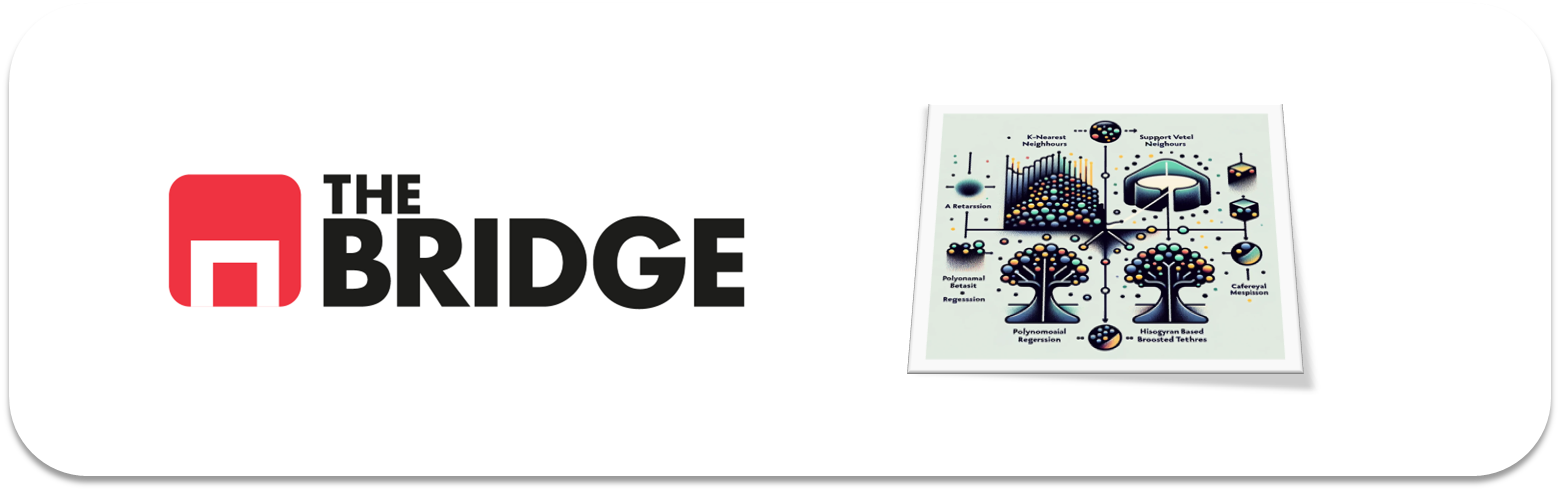

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score
)

from toolbox_ml.eda.core import (
    describe_df, tipifica_variables, 
    get_features_num_regression, 
    plot_features_num_regression, 
    get_features_cat_regression, 
    plot_features_cat_regression
)

import warnings
warnings.filterwarnings('ignore')

### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [2]:
df = pd.read_csv("./data/credit_npo.csv")
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

| Variable | Descripción |
|---|---|
| `SeriousDlqin2yrs` | **Variable objetivo.** Indica si la persona tuvo dificultades financieras graves en los dos años siguientes (1 = sí, 0 = no). |
| `RevolvingUtilizationOfUnsecuredLines` | Porcentaje de uso del crédito renovable (tarjetas, líneas de crédito) respecto al límite total concedido. Valor entre 0 y 1 (puede superar 1 si hay saldo superior al límite). |
| `age` | Edad del prestatario en años. |
| `NumberOfTime30-59DaysPastDueNotWorse` | Número de veces que el pago se retrasó entre 30 y 59 días (sin llegar a peor categoría). |
| `DebtRatio` | Ratio de deuda: pagos mensuales de deuda divididos entre el ingreso mensual bruto. |
| `MonthlyIncome` | Ingreso mensual bruto en dólares |
| `NumberOfOpenCreditLinesAndLoans` | Número total de préstamos y líneas de crédito abiertas (hipotecas, préstamos al consumo, etc.). |
| `NumberOfTimes90DaysLate` | Número de veces que el pago se retrasó 90 días o más. |
| `NumberRealEstateLoansOrLines` | Número de hipotecas y préstamos inmobiliarios abiertos. |
| `NumberOfTime60-89DaysPastDueNotWorse` | Número de veces que el pago se retrasó entre 60 y 89 días (sin llegar a peor categoría). |
| `NumberOfDependents` | Número de personas dependientes a cargo (excluido el propio solicitante). |

In [4]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
SeriousDlqin2yrs,int64,0.0,2,0.02
RevolvingUtilizationOfUnsecuredLines,float64,0.0,10764,85.86
age,int64,0.0,78,0.62
NumberOfTime30-59DaysPastDueNotWorse,int64,0.0,10,0.08
DebtRatio,float64,0.0,11547,92.1
MonthlyIncome,float64,5.75,4167,33.24
NumberOfOpenCreditLinesAndLoans,int64,0.0,43,0.34
NumberOfTimes90DaysLate,int64,0.0,13,0.1
NumberRealEstateLoansOrLines,int64,0.0,16,0.13
NumberOfTime60-89DaysPastDueNotWorse,int64,0.0,8,0.06


In [5]:
tipifica_variables(df, umbral_categoria=8, umbral_continua=30.0)


,nombre_variable,tipo_sugerido
0,SeriousDlqin2yrs,Binaria
1,RevolvingUtilizationOfUnsecuredLines,Numérica Continua
2,age,Numérica Discreta
3,NumberOfTime30-59DaysPastDueNotWorse,Numérica Discreta
4,DebtRatio,Numérica Continua
5,MonthlyIncome,Numérica Continua
6,NumberOfOpenCreditLinesAndLoans,Numérica Discreta
7,NumberOfTimes90DaysLate,Numérica Discreta
8,NumberRealEstateLoansOrLines,Numérica Discreta
9,NumberOfTime60-89DaysPastDueNotWorse,Numérica Discreta


In [6]:
col_numericas = [
    "RevolvingUtilizationOfUnsecuredLines", 
    "age", 
    "NumberOfTime30-59DaysPastDueNotWorse",
    "DebtRatio",
    "MonthlyIncome", 
    "NumberOfOpenCreditLinesAndLoans", 
    "NumberOfTimes90DaysLate", 
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents",
    "NumberOfTime60-89DaysPastDueNotWorse"
]

### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

Estamos ante un problema de clasificación binaria supervisada donde la variable target a predecir es `SeriousDlqin2yrs`

### #1.3
Pinta la distribución de frecuencias del target y coméntala

In [7]:
df["SeriousDlqin2yrs"].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.931084
1    0.068916
Name: proportion, dtype: float64

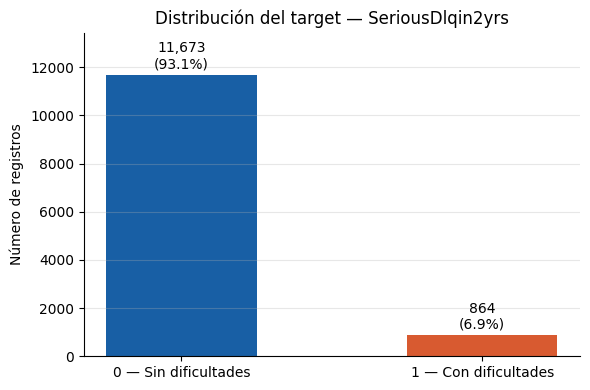

In [8]:
conteo = df['SeriousDlqin2yrs'].value_counts()
porcentaje = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    ['0 — Sin dificultades', '1 — Con dificultades'],
    conteo.values,
    color=['#185FA5', '#D85A30'],
    width=0.5
)

for bar, cnt, pct in zip(bars, conteo.values, porcentaje.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        f'{cnt:,}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_title('Distribución del target — SeriousDlqin2yrs', fontsize=12)
ax.set_ylabel('Número de registros')
ax.set_ylim(0, conteo.max() * 1.15)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [9]:
target = "SeriousDlqin2yrs"

La target está muy desbalanceada, solo hay un 6.9 % de la clase 1.

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

### Separación train y test

In [10]:
# Separación de train y test
X = df.drop(columns=target)
y= df[target]

# Debido al desbalanceo del target voy hacer un estratificado por esa variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {X_train.shape} Test: {X_test.shape}")
print("\n Distribución del target en train:", y_train.value_counts(normalize=True))
print("\n Distribución del target en test:", y_test.value_counts(normalize=True))


Train: (10029, 10) Test: (2508, 10)

 Distribución del target en train: SeriousDlqin2yrs
0    0.9311
1    0.0689
Name: proportion, dtype: float64

 Distribución del target en test: SeriousDlqin2yrs
0    0.931021
1    0.068979
Name: proportion, dtype: float64


### Análisis variables numéricas

In [11]:
X_train[col_numericas].describe()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfDependents,NumberOfTime60-89DaysPastDueNotWorse
count,10029.000000,10029.000000,10029.000000,10029.000000,9446.000000,10029.000000,10029.000000,10029.000000,9888.000000,10029.000000
mean,0.330685,52.059228,0.384884,1.950129,6828.929812,8.486389,0.229235,0.993120,0.815231,0.201516
std,0.370456,15.085691,3.714056,9.284826,11109.771346,5.153172,3.689186,1.130784,1.125188,3.671923
min,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.030323,41.000000,0.000000,0.142167,3475.750000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.163241,51.000000,0.000000,0.303945,5416.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.584406,62.000000,0.000000,0.507164,8290.750000,11.000000,0.000000,2.000000,1.000000,0.000000
max,6.000000,101.000000,98.000000,99.000000,702500.000000,49.000000,98.000000,19.000000,10.000000,98.000000


Antes de nada vamos a tratar los nulos de MonthyIncome

In [12]:
mediana_train = X_train["MonthlyIncome"].median()

mediana_clase0 = X_train.loc[y_train == 0, "MonthlyIncome"].median()
mediana_clase1 = X_train.loc[y_train == 1, "MonthlyIncome"].median()

print(f"Mediana clase 0: {mediana_clase0:.2f}")
print(f"Mediana clase 1: {mediana_clase1:.2f}")

X_train.loc[y_train == 0, "MonthlyIncome"] = X_train.loc[y_train == 0, "MonthlyIncome"].fillna(mediana_clase0)
X_train.loc[y_train == 1, "MonthlyIncome"] = X_train.loc[y_train == 1, "MonthlyIncome"].fillna(mediana_clase1)

X_test["MonthlyIncome"] = X_test["MonthlyIncome"].fillna(mediana_train)

Mediana clase 0: 5496.00
Mediana clase 1: 4583.00


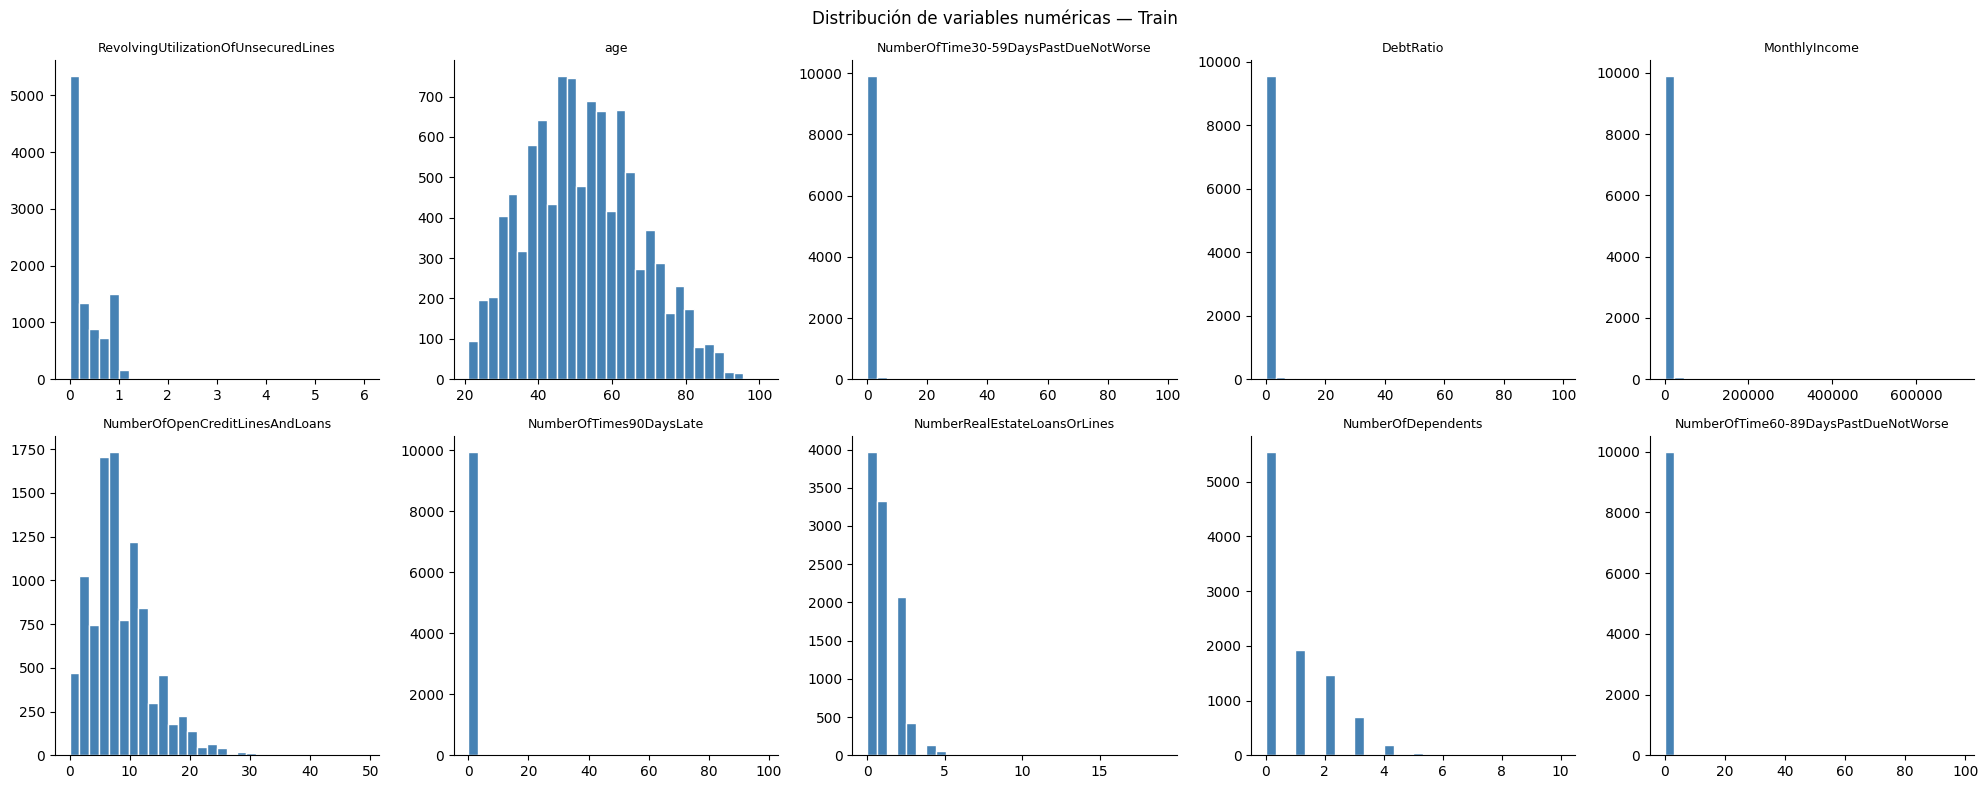

In [13]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(col_numericas):
    axes[i].hist(X_train[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].spines[['top', 'right']].set_visible(False)

plt.suptitle('Distribución de variables numéricas — Train', fontsize=12)
plt.tight_layout()
plt.show()

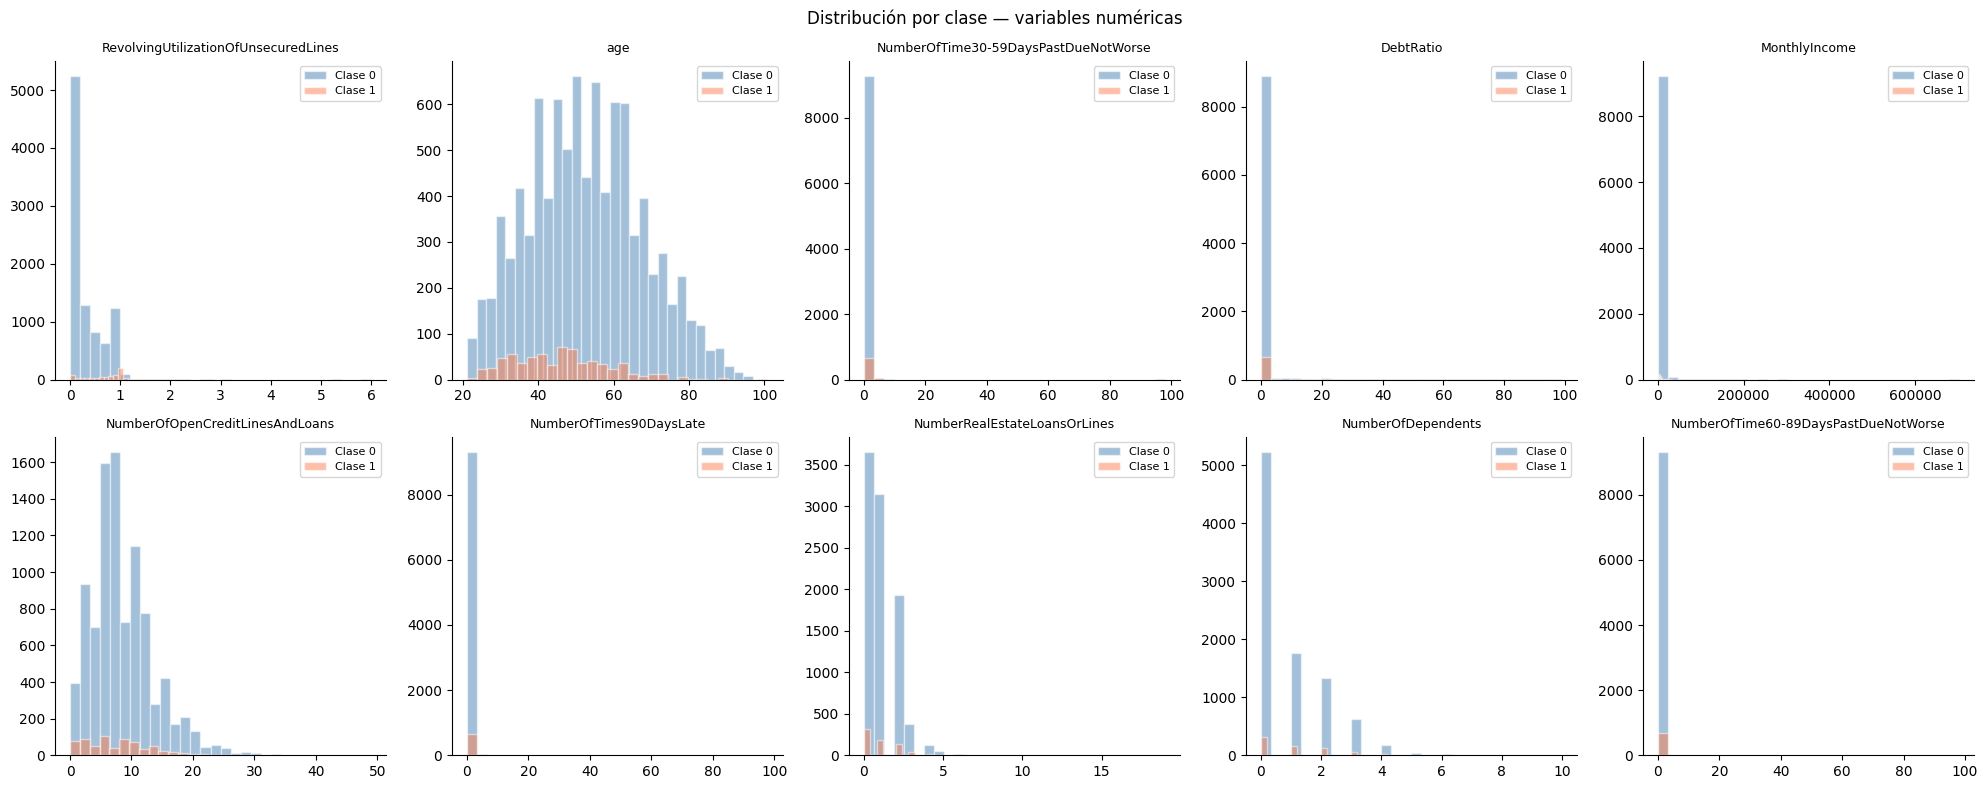

In [14]:
# --- Relación con el target ---
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(col_numericas):
    for clase, color in zip([0, 1], ['steelblue', 'coral']):
        mask = y_train == clase
        axes[i].hist(
            X_train.loc[mask, col],
            bins=30,
            alpha=0.5,
            color=color,
            edgecolor='white',
            label=f'Clase {clase}'
        )
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].spines[['top', 'right']].set_visible(False)

plt.suptitle('Distribución por clase — variables numéricas', fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
from scipy.stats import mannwhitneyu

for col in col_numericas:
    grupo0 = X_train.loc[y_train == 0, col]
    grupo1 = X_train.loc[y_train == 1, col]
    stat, pvalue = mannwhitneyu(grupo0, grupo1, alternative='two-sided')
    significativa = 'Significativa' if pvalue < 0.05 else 'No significativa'
    print(f"{col}: p-value={pvalue:.4f} → {significativa}")

RevolvingUtilizationOfUnsecuredLines: p-value=0.0000 → Significativa
age: p-value=0.0000 → Significativa
NumberOfTime30-59DaysPastDueNotWorse: p-value=0.0000 → Significativa
DebtRatio: p-value=0.0001 → Significativa
MonthlyIncome: p-value=0.0000 → Significativa
NumberOfOpenCreditLinesAndLoans: p-value=0.0001 → Significativa
NumberOfTimes90DaysLate: p-value=0.0000 → Significativa
NumberRealEstateLoansOrLines: p-value=0.0892 → No significativa
NumberOfDependents: p-value=nan → No significativa
NumberOfTime60-89DaysPastDueNotWorse: p-value=0.0000 → Significativa


Después de la observación de los gráficos y de los resultados del test de Mann Whitney U paso a seleccionar la variables numéricas que me quedo para el modelo

In [16]:
cols_numericas = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

In [17]:
# Verificación de nulos
print("Nulos en X_train:")
print(X_train[cols_numericas].isnull().sum())
print("\nNulos en X_test:")
print(X_test[cols_numericas].isnull().sum())

Nulos en X_train:
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberOfTime60-89DaysPastDueNotWorse    0
dtype: int64

Nulos en X_test:
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberOfTime60-89DaysPastDueNotWorse    0
dtype: int64


#### Tratamiento de variables numéricas selecionadas

In [18]:
# Hay 2 variables como maximo de 98 que considero que es un valor anómalo
cols_anom = ["NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTimes90DaysLate"]

# reemplazo el valor anomalo por nan tanto en train como en test
for col in cols_anom:
    X_train[col] = X_train[col].replace(98, np.nan) 
    X_test[col] = X_test[col].replace(98, np.nan)

# Ahora imputo la mediana a eses nan, en train y test
mediana_train = X_train[cols_anom].median()

X_train[cols_anom] = X_train[cols_anom].fillna(mediana_train)
X_test[cols_anom] = X_test[cols_anom].fillna(mediana_train)

In [19]:
# Investigar MonthlyIncome antes de transformar
print(X_train['MonthlyIncome'].describe())

count     10029.000000
mean       6749.168810
std       10786.862013
min           0.000000
25%        3538.000000
50%        5496.000000
75%        8000.000000
max      702500.000000
Name: MonthlyIncome, dtype: float64


In [20]:
# Crear variable categórica con los cuartiles como límites
bins = [-1, 3538, 5496, 8000, float('inf')]
labels = ['Bajo', 'Medio', 'Alto', 'Muy alto']

X_train['MonthlyIncome'] = pd.cut(
    X_train['MonthlyIncome'],
    bins=bins,
    labels=labels
)

X_test['MonthlyIncome'] = pd.cut(
    X_test['MonthlyIncome'],
    bins=bins,
    labels=labels
)

print(X_train['MonthlyIncome'].value_counts())

MonthlyIncome
Medio       2871
Bajo        2508
Muy alto    2496
Alto        2154
Name: count, dtype: int64


In [21]:
# Codificación ordinal — tiene sentido porque hay orden natural
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[['Bajo', 'Medio', 'Alto', 'Muy alto']])

X_train['MonthlyIncome'] = encoder.fit_transform(X_train[['MonthlyIncome']])
X_test['MonthlyIncome'] = encoder.transform(X_test[['MonthlyIncome']])

In [22]:
# Eliminamos a 'MonthlyIncome' de la lista de variables numéricas
cols_numericas = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

In [23]:
# Pasamos a medir la asimetría para tratar aquellas variables que lo necesiten
print("\n" + "=" * 60)
print("ASIMETRÍA (|skew| > 1 → distribución muy asimétrica)")
print("=" * 60)
skew = X_train[cols_numericas].skew().sort_values(ascending=False)
print(skew.round(3).to_string())
high_skew = skew[abs(skew) > 1].index.tolist()
print(f"\nFeatures con |skew| > 1: {high_skew}")


ASIMETRÍA (|skew| > 1 → distribución muy asimétrica)
NumberOfTime60-89DaysPastDueNotWorse    26.388
NumberOfTimes90DaysLate                  8.758
DebtRatio                                6.952
NumberOfTime30-59DaysPastDueNotWorse     3.907
RevolvingUtilizationOfUnsecuredLines     1.579
NumberOfOpenCreditLinesAndLoans          1.112
age                                      0.251

Features con |skew| > 1: ['NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'DebtRatio', 'NumberOfTime30-59DaysPastDueNotWorse', 'RevolvingUtilizationOfUnsecuredLines', 'NumberOfOpenCreditLinesAndLoans']


In [24]:
# variables numéricas selecionadas para corregir asimetría
cols_log = [
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'DebtRatio',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'RevolvingUtilizationOfUnsecuredLines',
    'NumberOfOpenCreditLinesAndLoans'
]

for col in cols_log:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

In [25]:
# Verificación — asimetría tras transformación
skewness_post = X_train[cols_numericas].skew().sort_values(ascending=False)
print(skewness_post)

NumberOfTime60-89DaysPastDueNotWorse    10.432076
NumberOfTimes90DaysLate                  5.122259
DebtRatio                                4.199255
NumberOfTime30-59DaysPastDueNotWorse     2.464004
RevolvingUtilizationOfUnsecuredLines     0.767553
age                                      0.251338
NumberOfOpenCreditLinesAndLoans         -0.789959
dtype: float64


In [26]:
# como hay variables que siguen muy asimétricas vamo a volver a paser el logaritmo
cols_log2 = [
    'NumberOfTime60-89DaysPastDueNotWorse', # 10.43 - sigue muy alto
    'NumberOfTimes90DaysLate',              # 5.12 - sigue muy alto
    'DebtRatio',                            # 4.20 - sigue muy alto
    'NumberOfTime30-59DaysPastDueNotWorse'  # 2.46 - sigue alto
]

for col in cols_log2:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

In [27]:
# Verificación
skewness_post2 = X_train[cols_numericas].skew().sort_values(ascending=False)
print(skewness_post2)

NumberOfTime60-89DaysPastDueNotWorse    5.496018
NumberOfTimes90DaysLate                 4.500014
DebtRatio                               2.807294
NumberOfTime30-59DaysPastDueNotWorse    2.132142
RevolvingUtilizationOfUnsecuredLines    0.767553
age                                     0.251338
NumberOfOpenCreditLinesAndLoans        -0.789959
dtype: float64


In [28]:
# Han mejorado un poco pero por último, vamos a pasar la raíz cúbica para a ver si conseguimos mejorar algo
cols_cbrt = [
    'NumberOfTime60-89DaysPastDueNotWorse',  # 5.50
    'NumberOfTimes90DaysLate',              # 4.50
    'DebtRatio',                            # 2.81
    'NumberOfTime30-59DaysPastDueNotWorse'  # 2.13
]

for col in cols_cbrt:
    X_train[col] = np.cbrt(X_train[col])
    X_test[col] = np.cbrt(X_test[col])

In [29]:
# Verificación
skewness_post3 = X_train[cols_numericas].skew().sort_values(ascending=False)
print(skewness_post3)

NumberOfTime60-89DaysPastDueNotWorse    4.150700
NumberOfTimes90DaysLate                 4.033027
NumberOfTime30-59DaysPastDueNotWorse    1.867611
RevolvingUtilizationOfUnsecuredLines    0.767553
age                                     0.251338
DebtRatio                              -0.346244
NumberOfOpenCreditLinesAndLoans        -0.789959
dtype: float64


In [30]:
# Por último vamos a proceder al escalado
scaler = StandardScaler()

X_train[cols_numericas] = scaler.fit_transform(X_train[cols_numericas])
X_test[cols_numericas] = scaler.transform(X_test[cols_numericas])

# Verificación
print("Media tras escalado (debe ser ~0):")
print(X_train[cols_numericas].mean().round(4))
print("\nDesviación típica tras escalado (debe ser ~1):")
print(X_train[cols_numericas].std().round(4))

Media tras escalado (debe ser ~0):
RevolvingUtilizationOfUnsecuredLines   -0.0
age                                    -0.0
NumberOfTime30-59DaysPastDueNotWorse    0.0
DebtRatio                              -0.0
NumberOfOpenCreditLinesAndLoans         0.0
NumberOfTimes90DaysLate                 0.0
NumberOfTime60-89DaysPastDueNotWorse   -0.0
dtype: float64

Desviación típica tras escalado (debe ser ~1):
RevolvingUtilizationOfUnsecuredLines    1.0
age                                     1.0
NumberOfTime30-59DaysPastDueNotWorse    1.0
DebtRatio                               1.0
NumberOfOpenCreditLinesAndLoans         1.0
NumberOfTimes90DaysLate                 1.0
NumberOfTime60-89DaysPastDueNotWorse    1.0
dtype: float64


### Establecimiento de features

In [31]:
features = cols_numericas + ['MonthlyIncome']

X_train_model = X_train[features]
X_test_model = X_test[features]

print("Shape X_train_model:", X_train_model.shape)
print("Shape X_test_model:", X_test_model.shape)
print("\nColumnas:", features)

Shape X_train_model: (10029, 8)
Shape X_test_model: (2508, 8)

Columnas: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse', 'MonthlyIncome']


### Elección de modelo

In [32]:
modelos = {
    'KNN': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, verbosity=0),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados = {}
for nombre, modelo in modelos.items():
    scores = cross_validate(
        modelo, X_train_model, y_train,
        cv=cv,
        scoring=['recall_macro', 'f1_macro', 'roc_auc'],
        n_jobs=-1
    )
    resultados[nombre] = {
        'recall_macro': round(scores['test_recall_macro'].mean(), 4),
        'recall_macro_std': round(scores['test_recall_macro'].std(), 4),
        'f1_macro': round(scores['test_f1_macro'].mean(), 4),
        'roc_auc': round(scores['test_roc_auc'].mean(), 4),
    }

df_resultados = pd.DataFrame(resultados).T.sort_values('recall_macro', ascending=False)
df_resultados

,recall_macro,recall_macro_std,f1_macro,roc_auc
XGBoost,0.5993,0.0255,0.6311,0.8066
CatBoost,0.5978,0.0242,0.6327,0.8413
Random Forest,0.5872,0.0151,0.6215,0.8220
Logistic Regression,0.5792,0.0104,0.6105,0.8489
KNN,0.5721,0.0156,0.5980,0.7198


## Conclusiones

### 1. XGBoost presenta el mejor Recall Macro
- Obtiene el mayor **Recall Macro (0.5993)**.
- Sin embargo, presenta una **variabilidad algo elevada (std 0.0255)**.
- Su **ROC AUC (0.8066)** es el más bajo entre los modelos boosting.

### 2. CatBoost ofrece el mejor equilibrio global
- Segundo mejor **Recall Macro (0.5978)**, muy próximo a XGBoost.
- Obtiene el mayor **F1 Macro (0.6327)**.
- Mantiene el **ROC AUC más alto (0.8413)**.
- Variabilidad ligeramente inferior a XGBoost (**std 0.0242**).

Por tanto, es el modelo que ofrece el mejor equilibrio entre capacidad de detección y rendimiento general.

### 3. Logistic Regression obtiene el segundo mejor ROC AUC
- Consigue un **ROC AUC de 0.8489**, el más alto de todos los modelos.
- Sin embargo, presenta valores inferiores en Recall Macro y F1 Macro.
- Es el modelo más estable (**std 0.0104**).

Esto sugiere que discrimina bien entre clases, pero utilizando el umbral de clasificación
por defecto no alcanza el rendimiento de los modelos boosting.

### 4. XGBoost, CatBoost y Random Forest muestran resultados competitivos
Las diferencias en Recall Macro son reducidas:

| Modelo | Recall Macro | std |
|---|---:|---:|
| XGBoost | 0.5993 | 0.0255 |
| CatBoost | 0.5978 | 0.0242 |
| Random Forest | 0.5872 | 0.0151 |

Considerando las desviaciones estándar, las diferencias entre XGBoost y CatBoost
podrían no ser estadísticamente significativas.

### 5. KNN es el modelo con peor desempeño
- Menor Recall Macro (0.5721).
- Menor F1 Macro (0.5980).
- ROC AUC significativamente inferior al resto (0.7198).

Por ello, se descarta como candidato para la solución final.

## Estabilidad de los modelos
La desviación estándar del Recall Macro permite evaluar la estabilidad durante la
validación cruzada:

- **Logistic Regression** presenta la menor variabilidad (0.0104).
- **Random Forest** muestra buena estabilidad (0.0151).
- **CatBoost** ofrece mejor rendimiento que XGBoost con menor variabilidad (0.0242 vs 0.0255).

## Conclusión final
Tras comparar los distintos algoritmos mediante validación cruzada, **CatBoost** se
selecciona como modelo final al presentar el mejor equilibrio entre Recall Macro,
F1 Macro y capacidad discriminativa (ROC AUC).

Aunque XGBoost supera ligeramente a CatBoost en Recall Macro (0.5993 vs 0.5978),
la diferencia es mínima y CatBoost compensa con mejor F1 Macro, mayor AUC y
menor variabilidad entre folds, lo que lo hace más fiable en producción.

### Optimización de hiperparámetros

In [33]:
param_grid = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'auto_class_weights': [None, 'Balanced', 'SqrtBalanced'],
    'l2_leaf_reg': [1, 3, 5, 10]
}

grid = GridSearchCV(
    CatBoostClassifier(random_state=42, verbose=0),
    param_grid,
    scoring='recall_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_model, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print(f"Mejor recall_macro CV: {grid.best_score_:.4f}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Mejores hiperparámetros: {'auto_class_weights': 'Balanced', 'depth': 6, 'iterations': 100, 'l2_leaf_reg': 3, 'learning_rate': 0.05}
Mejor recall_macro CV: 0.7748


### Evaluación de model en test

In [34]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.79      0.87      2335
           1       0.21      0.75      0.32       173

    accuracy                           0.78      2508
   macro avg       0.59      0.77      0.60      2508
weighted avg       0.92      0.78      0.83      2508



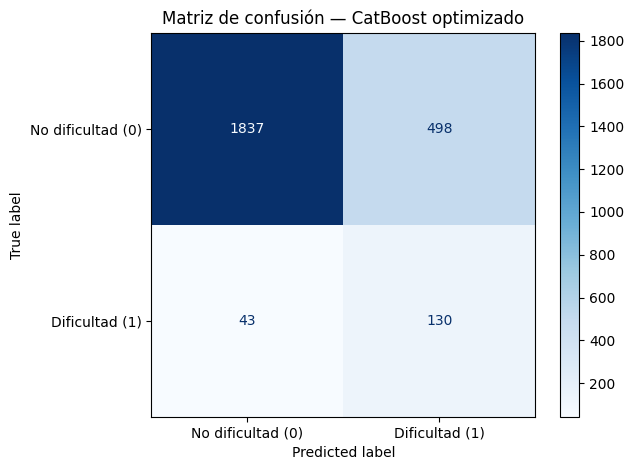

Verdaderos Negativos (TN): 1837
Falsos Positivos    (FP): 498
Falsos Negativos    (FN): 43
Verdaderos Positivos (TP): 130


In [35]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No dificultad (0)', 'Dificultad (1)']
)

disp.plot(cmap='Blues')
plt.title('Matriz de confusión — CatBoost optimizado')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos    (FP): {fp}")
print(f"Falsos Negativos    (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

## Conclusiones

### Proceso de modelado

Se ha desarrollado un pipeline completo de clasificación binaria para predecir si una persona
tendrá dificultades financieras graves en los dos próximos años, optimizando el **recall macro**
como métrica principal para obtener un compromiso equilibrado entre ambas clases.

### Preprocesado

- Se detectaron y trataron valores anómalos (98) en las variables de retrasos, reemplazándolos
  por `NaN` e imputándolos con la mediana calculada exclusivamente sobre el conjunto de train.
- Se descartaron 2 variables (`NumberOfDependents`, `NumberRealEstateLoansOrLines`) al no
  mostrar diferencias estadísticamente significativas entre clases (test Mann-Whitney, p-value > 0.05).
- `MonthlyIncome`, se transformó en variable ordinal con cuatro categorías (`Bajo`, `Medio`, `Alto`, `Muy alto`)   
  para eliminar el impacto de sus outliers extremos (máximo 702.500).
- Se analizó la asimetría de todas las variables numéricas, aplicando transformaciones para
  reducir el sesgo:
  - `log1p` — variables con skewness > 1.
  - `log1p` doble + raíz cúbica (`np.cbrt`) — variables con sesgo muy resistente
    (`NumberOfTimes90DaysLate`, `NumberOfTime30-59DaysPastDueNotWorse`,
    `NumberOfTime60-89DaysPastDueNotWorse`), cuya concentración extrema en 0 impidió
    una normalización completa.
- Se aplicó `StandardScaler` sobre las variables numéricas para homogeneizar la escala,
  calculando los parámetros exclusivamente sobre el conjunto de train y aplicándolos al test.

### Selección del modelo

Se compararon 5 modelos sin hiperparámetros mediante validación cruzada estratificada (5 folds):

| Modelo | Recall macro | F1 macro | AUC-ROC |
|---|---|---|---|
| XGBoost | 0.5993 | 0.6311 | 0.8066 |
| CatBoost | 0.5978 | 0.6327 | 0.8413 |
| Random Forest | 0.5872 | 0.6215 | 0.8220 |
| Logistic Regression | 0.5792 | 0.6105 | 0.8489 |
| KNN | 0.5721 | 0.5980 | 0.7198 |

**CatBoost** fue seleccionado por obtener el mejor equilibrio global entre Recall Macro,
F1 Macro y AUC-ROC. Aunque XGBoost superó ligeramente a CatBoost en Recall Macro
(0.5993 vs 0.5978), CatBoost compensó con mayor F1 Macro, mejor AUC-ROC y menor
variabilidad entre folds (std 0.0242 vs 0.0255), lo que lo hace más fiable en producción.

### Optimización

Tras `GridSearchCV` con 324 combinaciones y 5 folds (1620 entrenamientos), los mejores
hiperparámetros fueron:

- `auto_class_weights='Balanced'` — factor clave para gestionar el desbalanceo 93%/7%
- `depth=6`
- `iterations=100`
- `learning_rate=0.05`
- `l2_leaf_reg=3`

El recall macro mejoró de **0.5978** (baseline) a **0.7748** tras la optimización.

### Evaluación final en test

| Métrica | Valor |
|---|---|
| Recall macro | 0.77 |
| Recall clase 0 | 0.79 |
| Recall clase 1 | 0.75 |
| F1 macro | 0.60 |

### Análisis de errores

| | Predicho 0 | Predicho 1 |
|---|---|---|
| **Real 0** | 1837 ✅ | 498 ⚠️ |
| **Real 1** | 43 ❌ | 130 ✅ |

- **43 Falsos Negativos** — casos de impago no detectados. Es el error más costoso para
  el negocio ya que implica conceder crédito a clientes que van a impagar.
- **498 Falsos Positivos** — alarmas falsas. Suponen denegar crédito a clientes solventes,
  pero su coste para el negocio es menor.
- La precisión de la clase 1 es baja (0.21), consecuencia del fuerte desbalance existente
  y de la estrategia adoptada para priorizar la detección de la clase minoritaria mediante
  la optimización de Recall Macro — de cada 5 alertas lanzadas por el modelo, solo 1
  corresponde a un impago real.

## Conclusión general

El modelo final basado en CatBoost optimizado obtuvo un **Recall Macro de 0.77**, mejorando
en aproximadamente **18 puntos porcentuales** el rendimiento del modelo base (0.59).
La mejora se debió principalmente a la incorporación de ponderación automática de clases
mediante `auto_class_weights='Balanced'`, permitiendo compensar el fuerte desbalance presente
en la variable objetivo (93.1% frente a 6.9%).

En el conjunto de test, el modelo consiguió identificar correctamente el **75.1% de los casos
pertenecientes a la clase minoritaria**, cumpliendo el objetivo principal del proyecto de
maximizar la capacidad de detección de clientes con riesgo de dificultades financieras graves.

Esta mejora se obtuvo a costa de un aumento de falsos positivos y una precisión reducida
para la clase minoritaria (**0.21**), una consecuencia esperable al priorizar la sensibilidad
del modelo frente a eventos poco frecuentes. Sin embargo, desde una perspectiva de negocio,
este compromiso resulta razonable, ya que el coste potencial asociado a conceder crédito a
un cliente que posteriormente incumpla sus obligaciones financieras es superior al coste
derivado de rechazar una solicitud solvente.

En conjunto, los resultados muestran que el tratamiento explícito del desbalance de clases
constituye el principal factor de mejora del modelo y permite obtener una herramienta
predictiva útil para la identificación temprana de clientes de riesgo.